In [17]:
import torch
import os
import sys
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
import itertools

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)

from netrep.metrics import LinearMetric
from netrep.optimize import generate_blur_weights
from netrep.blur import add_random_blur_no_gray
from netrep.datasets import get_dataloaders

In [8]:
import matplotlib.pyplot as plt

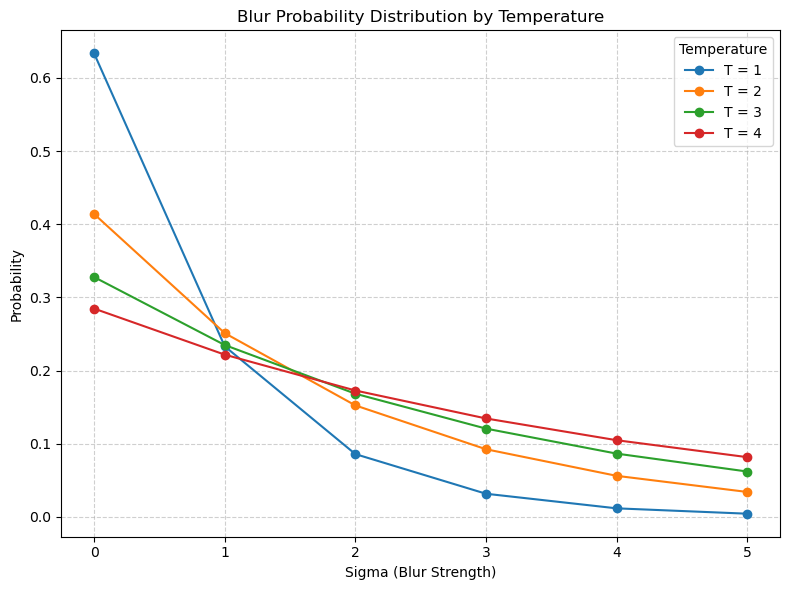

In [ ]:
sigmas = [0, 1, 2, 3, 4, 5]
plt.figure(figsize=(8, 6))

for T in range(1, 5):
    weights = generate_blur_weights(sigmas, temperature=T)
    plt.plot(sigmas, weights, marker='o', label=f"T = {T}")

plt.title("Blur Probability Distribution by Temperature")
plt.xlabel("Sigma (Blur Strength)")
plt.ylabel("Probability")
plt.xticks(sigmas)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Temperature")
plt.tight_layout()
plt.savefig("blur_distribution.png")
plt.show()

In [16]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

def visualize_blur_levels(images, sigmas):
    """Show one blurred example per sigma level from a single image."""
    # Pick one image (e.g., the first one in the batch)
    base_img = images[0].unsqueeze(0)  # shape: (1, C, H, W)

    # Create a mini-batch with one image per sigma
    base_batch = base_img.repeat(len(sigmas), 1, 1, 1)

    # Uniform weights to control sigma selection directly
    weights = [1.0] * len(sigmas)

    blurred_examples = add_random_blur_no_gray(base_batch, sigmas, weights, seed=123)

    # Unnormalize for visualization
    def unnormalize(t):
        mean = torch.tensor([0.485, 0.456, 0.406], device=t.device).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=t.device).view(3, 1, 1)
        return t * std + mean

    blurred_examples = unnormalize(blurred_examples).cpu().clamp(0, 1)

    # Plot
    plt.figure(figsize=(15, 3))
    for i, img in enumerate(blurred_examples):
        plt.subplot(1, len(sigmas), i + 1)
        plt.imshow(TF.to_pil_image(img))
        plt.title(f"σ = {sigmas[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
data_path = '/mnt/gpuxl/scc/AI_DATASETS/ImageNet/2012/imagenet'
train_loader, val_loader = get_dataloaders(data_path, batch_size=32, num_workers=4)

In [ ]:
images, _ = next(iter(train_loader))  # (B, C, H, W)
images = images.to('cpu')

visualize_blur_levels(images, sigmas=[0, 1, 2, 3, 4, 5])

In [3]:
activities = np.load('/mnt/home/the10/netrep-analysis/experiments/clean/results/activities.npz')

In [21]:
layer1_acts = activities['module.layer1.0']

In [29]:
from tqdm import tqdm
net_activities = []

for key in tqdm(activities.keys()):
    net_activities.extend(activities[key])

 12%|█▎        | 2/16 [00:24<02:55, 12.56s/it]

: 

In [ ]:
from tqdm import tqdm
net_activities = []

for key in tqdm(activities.keys()):
    net_activities.extend(activities[key])

X_train, X_test = [], []

for i, act in enumerate(net_activities):
    X1_train, X1_test = train_test_split(act, test_size=0.2, random_state=42)
    X_train.append(X1_train)
    X_test.append(X1_test)

In [ ]:
distmat = np.zeros((len(X_train), len(X_train)))

# use procruste's metrics
for i, j in itertools.combinations(range(3), 2):
    metric = LinearMetric(alpha=1.0, center_columns=True, score_method='angular')
    metric.fit(X_train[i], X_train[j])
    dist = metric.score(X_test[i], X_test[j])
    distmat[i, j] = dist

distmat += distmat.T

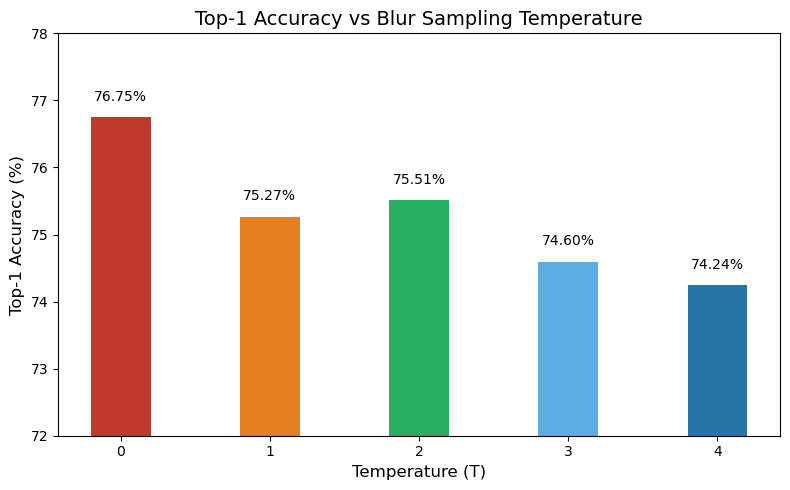

In [25]:
Ts = [0, 1, 2, 3, 4]
accs = [76.752, 75.268, 75.51, 74.596, 74.242]

Ts = [0, 1, 2, 3, 4]
accs = [76.752, 75.268, 75.51, 74.596, 74.242]

# Plot
plt.figure(figsize=(8, 5))
bar_width = 0.4  # smaller width for thinner bars
colors = [
    "#c0392b",  # CA1 - reddish
    "#e67e22",  # CA2 - orange
    "#27ae60",  # CA3 - green
    "#5dade2",  # DG  - blueish
    "#2874a6"   # CTX - darker blue
]
bars = plt.bar(Ts, accs, width=bar_width, color=colors)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.2, f"{yval:.2f}%", 
             ha='center', va='bottom', fontsize=10)

# Aesthetics
plt.title("Top-1 Accuracy vs Blur Sampling Temperature", fontsize=14)
plt.xlabel("Temperature (T)", fontsize=12)
plt.ylabel("Top-1 Accuracy (%)", fontsize=12)
plt.ylim(72, 78)
plt.xticks(Ts)
# plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

In [ ]:
embedding = MDS(n_components=200, metric= True, eps = 0.00001, normalized_stress='auto', dissimilarity='precomputed')
Z = embedding.fit_transform(np.abs(np.real(distmat)))
print(embedding.stress_)

In [ ]:
pca = PCA(n_components=3)
pcs1 = pca.fit_transform(Z)